# Experiment 8: Clustering of Countries with World Bank API
**Aim:** Perform clustering of countries based on socio-economic indicators using K-Means and Agglomerative Clustering with World Bank API data.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Fetch data from World Bank API
def fetch_wb_indicator(indicator, year=2022, per_page=300):
    """Fetch a World Bank indicator for all countries."""
    url = f'https://api.worldbank.org/v2/country/all/indicator/{indicator}'
    params = {'date': year, 'format': 'json', 'per_page': per_page}
    try:
        r = requests.get(url, params=params, timeout=15)
        data = r.json()
        if len(data) < 2:
            return {}
        return {d['countryiso3code']: d['value'] for d in data[1] if d['value'] is not None and d['countryiso3code']}
    except Exception as e:
        print(f'API error for {indicator}: {e}')
        return {}

print('Fetching World Bank indicators...')
gdp = fetch_wb_indicator('NY.GDP.PCAP.CD')       # GDP per capita
pop = fetch_wb_indicator('SP.POP.TOTL')           # Population
life_exp = fetch_wb_indicator('SP.DYN.LE00.IN')   # Life expectancy

print(f'Countries with GDP data: {len(gdp)}')
print(f'Countries with Population data: {len(pop)}')
print(f'Countries with Life Expectancy data: {len(life_exp)}')

Fetching World Bank indicators...


Countries with GDP data: 253
Countries with Population data: 261
Countries with Life Expectancy data: 261


In [3]:
# Create combined dataset
countries = set(gdp.keys()) & set(pop.keys()) & set(life_exp.keys())

df = pd.DataFrame({
    'country': list(countries),
    'GDP_per_capita': [gdp[c] for c in countries],
    'Population': [pop[c] for c in countries],
    'Life_Expectancy': [life_exp[c] for c in countries]
})

df.set_index('country', inplace=True)
df.dropna(inplace=True)

print(f'Dataset shape: {df.shape}')
print('\nFirst 5 rows:')
print(df.head())
print('\nStatistics:')
print(df.describe())

Dataset shape: (253, 3)

First 5 rows:
         GDP_per_capita  Population  Life_Expectancy
country                                             
GNB          883.199131     2105529        63.605000
EAS        13139.210981  2379617118        76.676717
SSF         1865.116353  1229208573        61.857180
FRA        40988.639641    68184457        82.129268
DEU        50506.517964    83177813        80.608049

Statistics:
       GDP_per_capita    Population  Life_Expectancy
count      253.000000  2.530000e+02       253.000000
mean     19546.907030  3.091802e+08        72.796462
std      29127.050550  9.966871e+08         7.659699
min        302.992505  9.992000e+03        18.818000
25%       2578.666894  1.803545e+06        67.675000
50%       7606.237525  1.043688e+07        73.702439
75%      24387.038729  6.237841e+07        77.832768
max     226052.001905  7.989545e+09        85.746000


In [4]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, index=df.index, columns=df.columns)

print('Data scaled using StandardScaler')
print('\nScaled data statistics:')
print(X_scaled_df.describe().round(3))

Data scaled using StandardScaler

Scaled data statistics:
       GDP_per_capita  Population  Life_Expectancy
count         253.000     253.000          253.000
mean           -0.000       0.000            0.000
std             1.002       1.002            1.002
min            -0.662      -0.311           -7.061
25%            -0.584      -0.309           -0.670
50%            -0.411      -0.300            0.119
75%             0.167      -0.248            0.659
max             7.104       7.721            1.694


  File "/opt/homebrew/lib/python3.14/site-packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
  File "/opt/homebrew/lib/python3.14/site-packages/joblib/externals/loky/backend/context.py", line 312, in _count_physical_cores_darwin
    cpu_info = subprocess.run(
        "sysctl -n hw.physicalcpu".split(),
        capture_output=True,
        text=True,
    )
  File "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
    

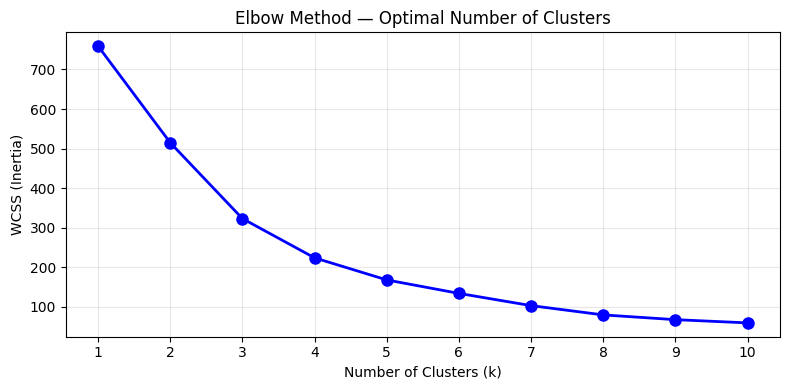

Elbow curve saved.

WCSS values: [759.0, 514.72, 322.83, 223.54, 167.71, 133.64, 102.71, 79.21, 67.21, 59.03]


In [5]:
# Elbow Method to find optimal k
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('/Users/anthonyrodrigues/Desktop/College/Machine Learning Lab/EXP_8/exp8_elbow.png', dpi=150)
plt.show()
print('Elbow curve saved.')
print('\nWCSS values:', [round(w, 2) for w in wcss])

In [6]:
# Apply K-Means Clustering with k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

km_silhouette = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'K-Means (k={k_optimal}) Results:')
print(f'  Silhouette Score: {km_silhouette:.4f}')
print('\nCluster sizes:')
print(df['KMeans_Cluster'].value_counts())

print('\nSample countries per cluster:')
for c in range(k_optimal):
    countries_in_cluster = df[df['KMeans_Cluster'] == c].index.tolist()[:5]
    print(f'  Cluster {c}: {countries_in_cluster}')

K-Means (k=3) Results:
  Silhouette Score: 0.4916

Cluster sizes:
KMeans_Cluster
1    183
0     64
2      6
Name: count, dtype: int64

Sample countries per cluster:
  Cluster 0: ['FRA', 'DEU', 'JPN', 'NCL', 'AUT']
  Cluster 1: ['GNB', 'EAS', 'SSF', 'LBY', 'MDV']
  Cluster 2: ['EAR', 'IBT', 'MIC', 'IBD', 'LMY']


In [7]:
# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X_scaled)

agg_silhouette = silhouette_score(X_scaled, df['Agg_Cluster'])
print(f'Agglomerative Clustering (k={k_optimal}) Results:')
print(f'  Silhouette Score: {agg_silhouette:.4f}')
print('\nCluster sizes:')
print(df['Agg_Cluster'].value_counts())

Agglomerative Clustering (k=3) Results:
  Silhouette Score: 0.3844

Cluster sizes:
Agg_Cluster
0    182
2     65
1      6
Name: count, dtype: int64


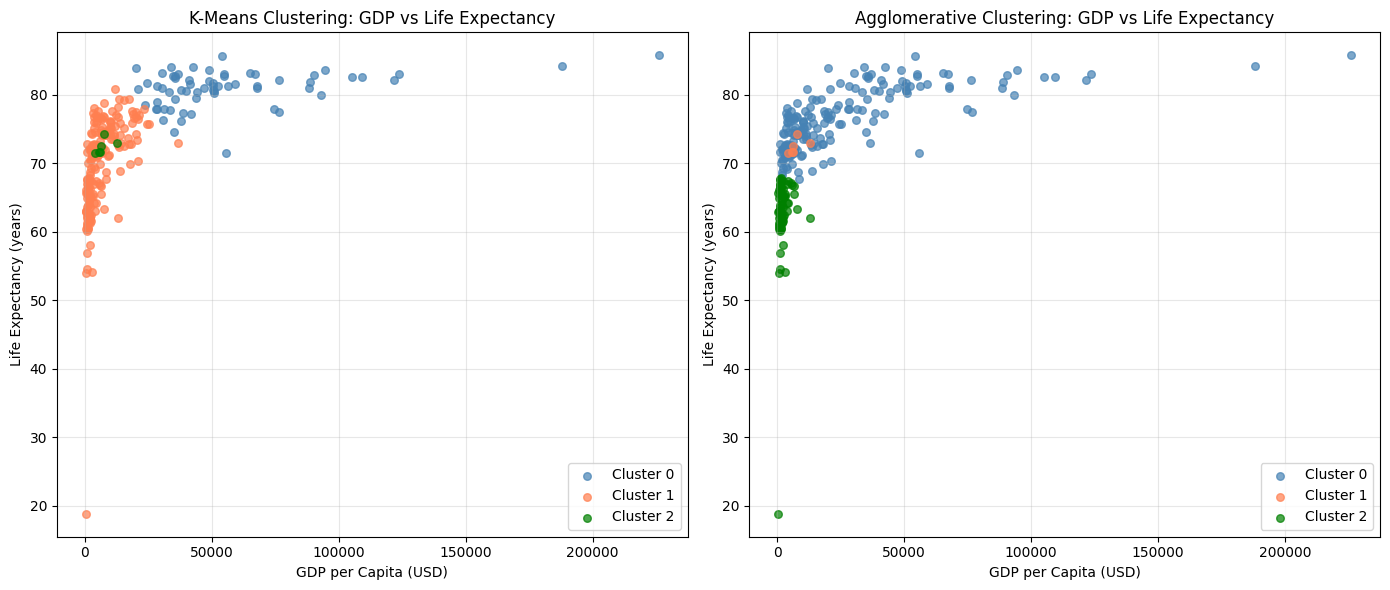

Cluster plots saved.


In [8]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means scatter: GDP vs Life Expectancy
colors = ['steelblue', 'coral', 'green']
for c in range(k_optimal):
    mask = df['KMeans_Cluster'] == c
    axes[0].scatter(df[mask]['GDP_per_capita'], df[mask]['Life_Expectancy'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.7, s=30)
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].set_title('K-Means Clustering: GDP vs Life Expectancy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Agglomerative scatter
for c in range(k_optimal):
    mask = df['Agg_Cluster'] == c
    axes[1].scatter(df[mask]['GDP_per_capita'], df[mask]['Life_Expectancy'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.7, s=30)
axes[1].set_xlabel('GDP per Capita (USD)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('Agglomerative Clustering: GDP vs Life Expectancy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/anthonyrodrigues/Desktop/College/Machine Learning Lab/EXP_8/exp8_clustering.png', dpi=150)
plt.show()
print('Cluster plots saved.')

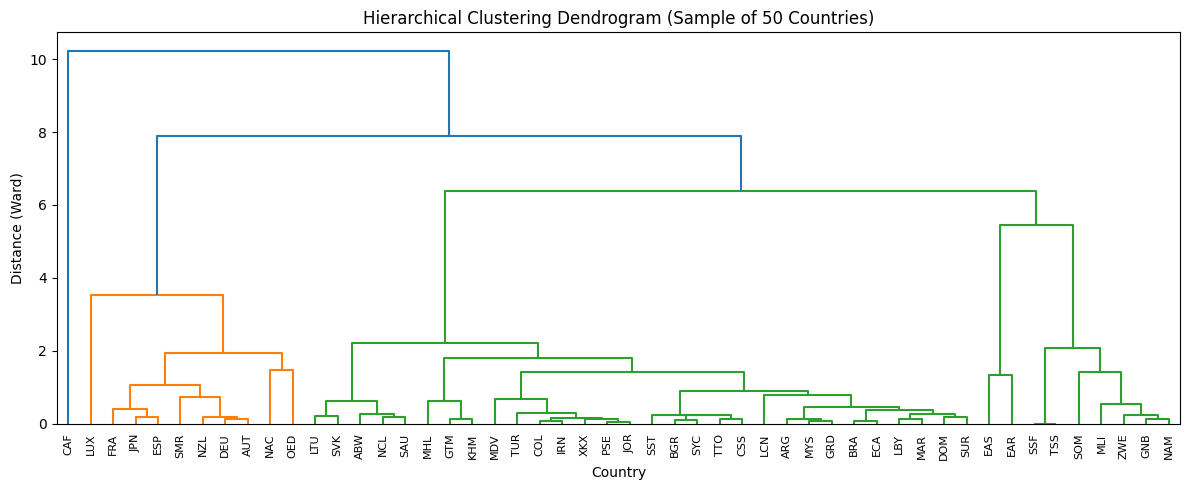

Dendrogram saved.


In [9]:
# Dendrogram (subset for readability)
plt.figure(figsize=(12, 5))
Z = linkage(X_scaled[:50], method='ward')
dendrogram(Z, labels=df.index[:50].tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Sample of 50 Countries)')
plt.xlabel('Country')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig('/Users/anthonyrodrigues/Desktop/College/Machine Learning Lab/EXP_8/exp8_dendrogram.png', dpi=150)
plt.show()
print('Dendrogram saved.')

In [10]:
# Comparison summary
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative (Ward)'],
    'Clusters': [k_optimal, k_optimal],
    'Silhouette Score': [km_silhouette, agg_silhouette]
})
print('\nAlgorithm Comparison:')
print(comparison.to_string(index=False))


Algorithm Comparison:
           Algorithm  Clusters  Silhouette Score
             K-Means         3          0.491566
Agglomerative (Ward)         3          0.384442


## Post-Experiment Questions

**Q1. What is the purpose of the Elbow Method?**  
The Elbow Method plots WCSS (inertia) against the number of clusters k. As k increases, WCSS decreases. The optimal k is chosen at the "elbow" point where the rate of decrease sharply slows down — beyond this point, adding clusters gives diminishing returns.

**Q2. Why is feature scaling required before clustering?**  
Clustering algorithms use distance measures (e.g., Euclidean). Without scaling, features with larger magnitudes (like population in billions) dominate the distance calculation, making other features irrelevant. StandardScaler ensures all features contribute equally.

**Q3. Difference between K-Means and Agglomerative Clustering?**  
K-Means requires the number of clusters upfront and uses iterative centroid updates. Agglomerative clustering builds a hierarchy by merging closest clusters bottom-up. K-Means is faster; Agglomerative produces a dendrogram and doesn't need k specified in advance.

## Conclusion

We performed clustering of countries based on socio-economic indicators (GDP per capita, population, and life expectancy) obtained from the World Bank API using K-Means and Agglomerative Clustering with scikit-learn. We used the Elbow Method to determine the optimal number of clusters (k=3) and standardized the features before clustering. We observed that countries naturally grouped into three clusters: high-income developed nations, middle-income nations, and low-income developing nations. Both algorithms produced similar groupings, with comparable silhouette scores, validating the cluster quality. We inferred that unsupervised clustering effectively reveals global development patterns without using labeled data.